In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import numpy.random as npr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec  # Import for custom grid layout
from sklearn.model_selection import KFold
import pickle

from imports import *
from config import dir_config
from src.utils import pmf_utils, glm_hmm_utils

In [3]:
compiled_dir = Path(dir_config.data.compiled)
processed_dir = Path(dir_config.data.processed)

In [4]:
with open(Path(processed_dir, 'sessions_metadata.csv'), 'r') as f:
    session_metadata = pd.read_csv(f)

## Prepare data

In [5]:

# Pre-allocate lists for session data
behavior_df = pd.DataFrame(columns=["session_id", "prior_direction", "GP_trial_num", "prob_toRF", "signed_coherence", "target", "choice", "outcome","response_time"])


# Process each session
for _, session_row in session_metadata.iterrows():

    session_id = session_row["session_id"]
    prior_direction = "L" if (session_row["prior_direction"] == "toRF" and session_row["RF_side"] == "L") or (session_row["prior_direction"] == "awayRF" and session_row["RF_side"] == "R") else "R"

    # Read trial data for each session
    trial_data = pd.read_csv(Path(compiled_dir, session_id, f"{session_id}_trial.csv"), index_col=None)
    GP_trial_data = trial_data[trial_data.task_type == 1].reset_index()


    # Get valid indices based on outcomes
    valid_idx = np.where(GP_trial_data.outcome >= 0)[0]

    coherence = GP_trial_data.coherence.values[valid_idx]
    target = GP_trial_data.target.values[valid_idx].astype("int")
    choices = GP_trial_data.choice.values[valid_idx].astype("int")
    outcomes = GP_trial_data.outcome.values[valid_idx].astype("int")

    if session_row["RF_side"] == "L": # flip target and choice to L/R as 0/1
        target = 1 - target
        choices = 1 - choices

    signed_coherence = coherence * (target * 2 - 1)
    GP_trial_num = np.array(GP_trial_data.trial_number)[valid_idx]
    prob_toRF = np.array(GP_trial_data.prob_toRF)[valid_idx]


    behavior_df = pd.concat([behavior_df, pd.DataFrame({
        "session_id": session_id,
        "prior_direction": prior_direction,
        "GP_trial_num": GP_trial_num,
        "prob_toRF": prob_toRF,
        "signed_coherence": signed_coherence,
        "target": target,
        "choice": choices,
        "outcome": outcomes,
        "response_time": GP_trial_data.reaction_time.values[valid_idx]
    })], ignore_index=True)


#### utils

In [6]:
def psychometric_fit(stimulus, choices, expected_choice_prob, ax, color, label, n_sample=10):
	data = {"signed_coherence": np.array(stimulus) * 100, "choice": choices}
	x_data, y_data, model, x_model, y_model = pmf_utils.get_psychometric_data(data)

	x_model_hat, y_model_hat = np.full((n_sample, len(x_model)), np.nan), np.full((n_sample, len(y_model)), np.nan)

	ax.plot(x_data, y_data, "o", color=color)
	ax.plot(x_model, y_model, color=color, label=label)
	ax.plot(np.mean(x_model_hat, axis=0), np.mean(y_model_hat, axis=0), color=color, linestyle="--")
	ax.fill_between(np.mean(x_model_hat, axis=0), np.mean(y_model_hat, axis=0) - np.std(y_model_hat, axis=0), np.mean(y_model_hat, axis=0) + np.std(y_model_hat, axis=0), color=color, alpha=0.3)

	ax.set_xlim(min(x_data), max(x_data))
	ax.set_xlabel("Coherence")
	ax.set_ylabel("choices toRF")
	ax.set_title("Psychometric fits", fontsize=15)
	ax.legend()

In [7]:
def latency_probabilities_plot(data, ax, color, alpha=1, label=None):
    _, y_data, _, _, _ = pmf_utils.get_psychometric_data(data)
    _, _, rt_mean, _, _ = pmf_utils.get_chronometric_data(data)
    ax.plot(np.sort(y_data), rt_mean[np.argsort(y_data)], marker='o', color=color, alpha=alpha, label=label)
    return y_data, rt_mean


In [8]:
def plot_double_errorbars(choices, rt, ax, color, label, **plot_kwargs):
    from scipy import stats
    """
    Plot double error bars for choices and reaction times.
    """
    mean_choices = np.mean(choices, axis=0)
    mean_rt = np.mean(rt, axis=0)
    sem_choices = stats.sem(choices, axis=0)
    sem_rt = stats.sem(rt, axis=0)
    ax.plot(mean_choices, mean_rt, marker='o', color=color, label=label, **plot_kwargs)
    ax.errorbar(mean_choices, mean_rt, xerr=sem_choices, yerr=sem_rt, fmt='o', capsize=4, color=color)
    ax.legend()

### PMF

In [9]:
left_sessions, right_sessions = 0,0

for session_id in session_metadata["session_id"]:
    session_data = behavior_df[behavior_df.session_id == session_id]

    if session_data.empty:
        continue  # Skip if no data

    equal_data = session_data[session_data.prob_toRF == 50]
    unequal_data = session_data[session_data.prob_toRF != 50]

    # Get prior direction safely
    prior_dir = session_data["prior_direction"].iloc[0]
    if prior_dir == "L":
        left_sessions += 1
    elif prior_dir == "R":
        right_sessions += 1
left_sessions, right_sessions

(24, 21)

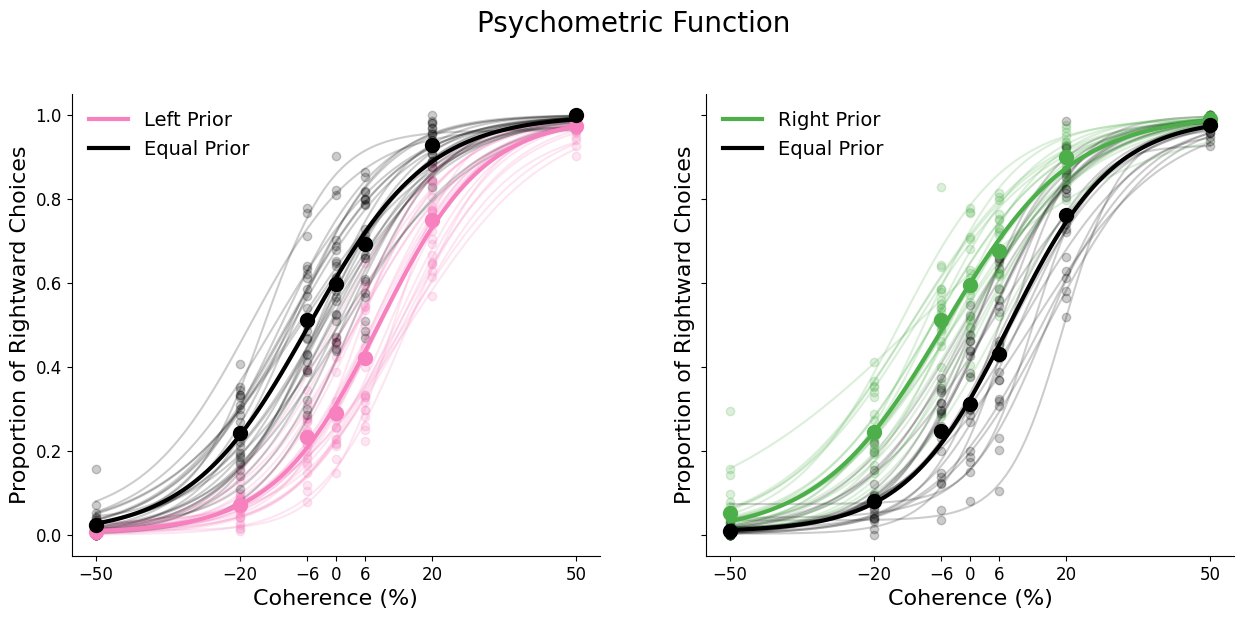

In [10]:
alpha_value = 0.2
fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

eq_color = "black"
# uneq_color = {'L':  "#974810", 'R': "#377eb8"}  # Differentiate directions
uneq_color = {'L':  "#F781BF", 'R': "#4DAF4A"}  # Differentiate directions

eq_left_model, uneq_left_model = {'alpha': [], 'beta': [], 'lapse_rate': []}, {'alpha': [], 'beta': [], 'lapse_rate': []}
eq_right_model, uneq_right_model = {'alpha': [], 'beta': [], 'lapse_rate': []}, {'alpha': [], 'beta': [], 'lapse_rate': []}

for session_id in session_metadata["session_id"]:
    session_data = behavior_df[behavior_df.session_id == session_id]

    if session_data.empty:
        continue  # Skip if no data

    equal_data = session_data[session_data.prob_toRF == 50]
    unequal_data = session_data[session_data.prob_toRF != 50]

    # Get prior direction safely
    prior_dir = session_data["prior_direction"].iloc[0]
    color = uneq_color.get(prior_dir)

    # Get psychometric data
    x_eq_data, y_eq_data, eq_model, x_eq_model, y_eq_model = pmf_utils.get_psychometric_data(equal_data, model_type='logit_3')
    x_uneq_data, y_uneq_data, uneq_model, x_uneq_model, y_uneq_model = pmf_utils.get_psychometric_data(unequal_data, model_type='logit_3')


    if prior_dir == "L":
        ax = axs[0]
        eq_left_model['alpha'].append(eq_model.coefs_['mean'])
        eq_left_model['beta'].append(eq_model.coefs_['var'])
        eq_left_model['lapse_rate'].append(eq_model.coefs_['lapse_rate'])
        uneq_left_model['alpha'].append(uneq_model.coefs_['mean'])
        uneq_left_model['beta'].append(uneq_model.coefs_['var'])
        uneq_left_model['lapse_rate'].append(uneq_model.coefs_['lapse_rate'])
    else:
        ax = axs[1]
        eq_right_model['alpha'].append(eq_model.coefs_['mean'])
        eq_right_model['beta'].append(eq_model.coefs_['var'])
        eq_right_model['lapse_rate'].append(eq_model.coefs_['lapse_rate'])
        uneq_right_model['alpha'].append(uneq_model.coefs_['mean'])
        uneq_right_model['beta'].append(uneq_model.coefs_['var'])
        uneq_right_model['lapse_rate'].append(uneq_model.coefs_['lapse_rate'])

    ax.plot(x_uneq_data, y_uneq_data, "o", color=color, alpha=alpha_value)
    ax.plot(x_uneq_model, y_uneq_model, linestyle="-", color=color, alpha=alpha_value)
    ax.plot(x_eq_data, y_eq_data, "o", color=eq_color, alpha=alpha_value)
    ax.plot(x_eq_model, y_eq_model, color=eq_color, alpha=alpha_value)

left_prior_data = behavior_df[behavior_df.prior_direction == "L"]
right_prior_data = behavior_df[behavior_df.prior_direction == "R"]

for key in eq_left_model.keys():
    eq_left_model[key] = np.array(eq_left_model[key])
    uneq_left_model[key] = np.array(uneq_left_model[key])
    eq_right_model[key] = np.array(eq_right_model[key])
    uneq_right_model[key] = np.array(uneq_right_model[key])

x_left_eq_data, y_left_eq_data, _, x_left_eq_model, y_left_eq_model = pmf_utils.get_psychometric_data(left_prior_data[left_prior_data.prob_toRF == 50], model_type='logit_3')
x_left_uneq_data, y_left_uneq_data, _, x_left_uneq_model, y_left_uneq_model = pmf_utils.get_psychometric_data(left_prior_data[left_prior_data.prob_toRF != 50], model_type='logit_3')

x_right_eq_data, y_right_eq_data, _, x_right_eq_model, y_right_eq_model = pmf_utils.get_psychometric_data(right_prior_data[right_prior_data.prob_toRF == 50], model_type='logit_3')
x_right_uneq_data, y_right_uneq_data, _, x_right_uneq_model, y_right_uneq_model = pmf_utils.get_psychometric_data(right_prior_data[right_prior_data.prob_toRF != 50], model_type='logit_3')

axs[0].plot(x_left_eq_data, y_left_uneq_data, "o", color=uneq_color["L"], markersize =10)
axs[0].plot(x_left_uneq_model, y_left_uneq_model, linestyle="-", color=uneq_color["L"],linewidth=3, label="Left Prior")
axs[0].plot(x_left_eq_data, y_left_eq_data, "o", color=eq_color, markersize =10)
axs[0].plot(x_left_eq_model, y_left_eq_model, color=eq_color,linewidth=3, label="Equal Prior")

axs[1].plot(x_right_eq_data, y_right_uneq_data, "o", color=uneq_color["R"], markersize =10)
axs[1].plot(x_right_uneq_model, y_right_uneq_model, linestyle="-", color=uneq_color["R"],linewidth=3, label="Right Prior")
axs[1].plot(x_right_eq_data, y_right_eq_data, "o", color=eq_color, markersize =10)
axs[1].plot(x_right_eq_model, y_right_eq_model, color=eq_color,linewidth=3, label="Equal Prior")

for ax in axs:
    ax.set_xticks([-50,-20,-6,0,6,20,50])
    ax.tick_params(axis='both', labelsize=12)
    ax.set_xlabel('Coherence (%)',fontsize=16)
    ax.set_ylabel('Proportion of Rightward Choices',fontsize=16)
    ax.spines['top'].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=14,frameon=False)

# axs[0].set_title("Left Prior Sessions", fontsize=20, pad=30)
# axs[1].set_title("Right Prior Sessions", fontsize=20, pad=30)

plt.suptitle("Psychometric Function",fontsize=20, y=1.02);


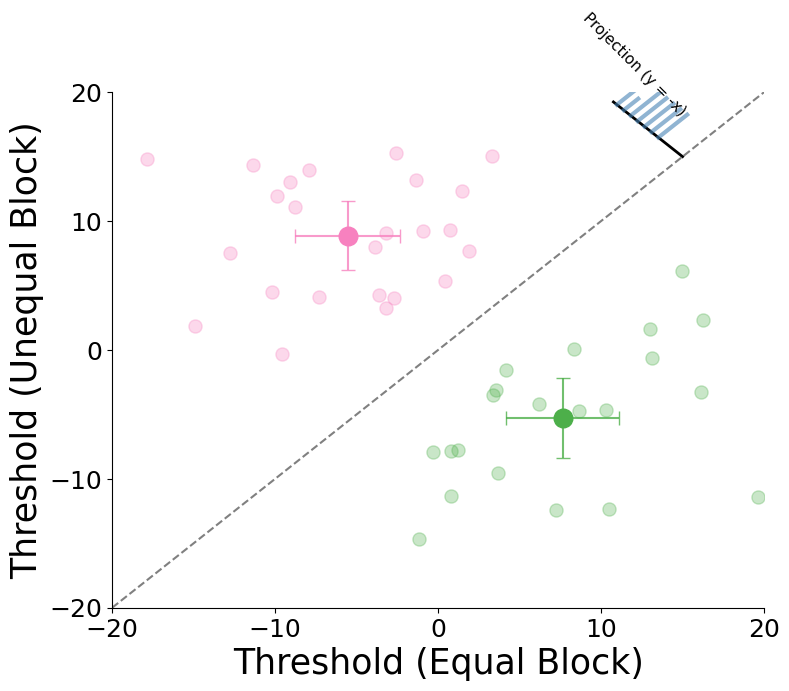

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))

ax_range = ([-20,20])

ax.scatter(eq_left_model['alpha'],uneq_left_model['alpha'],color=uneq_color["L"], s=90, alpha=0.3)
ax.scatter(eq_right_model['alpha'],uneq_right_model['alpha'],color=uneq_color["R"], s=90, alpha=0.3)# Left Prior Mean and Error
mean_eq_left = np.mean(eq_left_model['alpha'])
mean_uneq_left = np.mean(uneq_left_model['alpha'])
sem_eq_left = np.std(eq_left_model['alpha']) / np.sqrt(len(eq_left_model))
sem_uneq_left = np.std(uneq_left_model['alpha']) / np.sqrt(len(uneq_left_model))

ax.scatter(mean_eq_left, mean_uneq_left, color=uneq_color["L"], s=180)
ax.errorbar(mean_eq_left, mean_uneq_left,
             xerr=sem_eq_left, yerr=sem_uneq_left,
             fmt='o', color=uneq_color["L"], capsize=5, alpha=0.8)

# Right Prior Mean and Error
mean_eq_right = np.mean(eq_right_model['alpha'])
mean_uneq_right = np.mean(uneq_right_model['alpha'])
sem_eq_right = np.std(eq_right_model['alpha']) / np.sqrt(len(eq_right_model))
sem_uneq_right = np.std(uneq_right_model['alpha']) / np.sqrt(len(uneq_right_model))

ax.scatter(mean_eq_right, mean_uneq_right, color=uneq_color["R"], s=180)
ax.errorbar(mean_eq_right, mean_uneq_right,
             xerr=sem_eq_right, yerr=sem_uneq_right,
             fmt='o', color=uneq_color["R"], capsize=5, alpha=0.8)



ax.scatter([], [], color=uneq_color["R"], label="Right Prior", s=90)
ax.scatter([], [], color=uneq_color["L"], label = "Left Prior", s=90)
ax.set_xlim(ax_range)
ax.set_ylim(ax_range)
ax.plot(ax_range,ax_range,color='gray',linestyle='--')
ax.set_xticks(np.arange(ax_range[0],ax_range[1]+1,10))
ax.set_yticks(np.arange(ax_range[0],ax_range[1]+1,10))
ax.tick_params(axis='both', labelsize=18)
ax.set_xlabel('Threshold (Equal Block)',fontsize=25)
ax.set_ylabel('Threshold (Unequal Block)',fontsize=25)
ax.spines['top'].set_visible(False)
ax.spines["right"].set_visible(False)
# plt.legend(bbox_to_anchor=(0.8 , 0.82), loc='upper left', fontsize=12, frameon=True);

x0, y0 = 15, 15  # base point
axis_length = 6  # how far perpendicular axis extends

# Perpendicular direction (unit vector)
n = np.array([1, -1]) / np.sqrt(2)

# Draw perpendicular axis itself
ax.plot(
    [x0, x0 - n[0]*axis_length],
    [y0, y0 - n[1]*axis_length],
    color="k", lw=2
)

# --- Draw histogram bars along that perpendicular line ---
for c, count in zip(centers, counts):
    # Base point for each bar (move along the perpendicular axis)
    base = np.array([x0, y0]) - (c / 15) * axis_length * n
    # Bar extends outward (perpendicular to the axis)
    bar_dir = np.array([-n[1], n[0]])  # 90° rotated vector
    tip = base + count * bar_dir
    ax.plot([base[0], tip[0]], [base[1], tip[1]], color='steelblue', lw=3, alpha=0.6)


plt.tight_layout()
plt.show()


In [13]:
left_proj

array([21.86287306, 10.15476974, 20.27656095,  6.49488387, 25.71082719,
       14.70907654,  6.7042315 , 11.89709581,  8.61285789,  7.94459263,
       11.40167415,  9.2381646 , 16.81084827, 14.53592797, 12.22994015,
       21.86651086, 17.84116657, 10.8698281 ,  5.73476196, 22.14622545,
       19.88869296,  4.97386   , 11.79624708, 32.68744077])

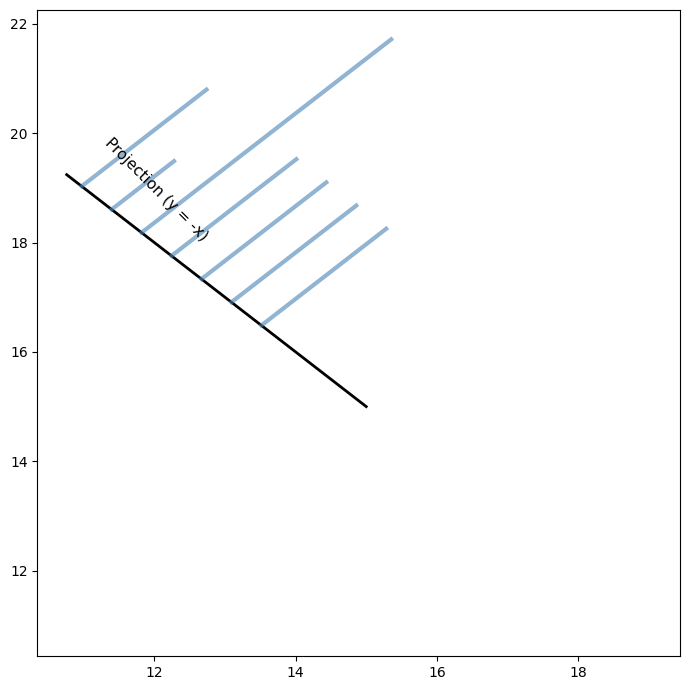

In [15]:
left_proj = uneq_left_model['alpha'] - eq_left_model['alpha']
right_proj = uneq_right_model['alpha'] - eq_right_model['alpha']

counts, bins = np.histogram(left_proj, bins=20, range=(-15, 15))
counts = counts / counts.max() * 5  # scale for visibility
centers = (bins[:-1] + bins[1:]) / 2


from matplotlib.transforms import Affine2D
from matplotlib import patches
fig, ax = plt.subplots(figsize=(7, 7))
x0, y0 = 15, 15  # base point
axis_length = 6  # how far perpendicular axis extends

# Perpendicular direction (unit vector)
n = np.array([1, -1]) / np.sqrt(2)

# Draw perpendicular axis itself
ax.plot(
    [x0, x0 - n[0]*axis_length],
    [y0, y0 - n[1]*axis_length],
    color="k", lw=2
)

# --- Draw histogram bars along that perpendicular line ---
for c, count in zip(centers, counts):
    # Base point for each bar (move along the perpendicular axis)
    base = np.array([x0, y0]) - (c / 15) * axis_length * n
    # Bar extends outward (perpendicular to the axis)
    bar_dir = np.array([-n[1], n[0]])  # 90° rotated vector
    tip = base + count * bar_dir
    ax.plot([base[0], tip[0]], [base[1], tip[1]], color='steelblue', lw=3, alpha=0.6)

# Label the perpendicular axis
ax.text(
    x0 - n[0]*axis_length*0.7,
    y0 - n[1]*axis_length*0.7,
    "Projection (y = -x)",
    rotation=-45,
    ha='center', va='bottom', fontsize=11
)

plt.tight_layout()
plt.show()


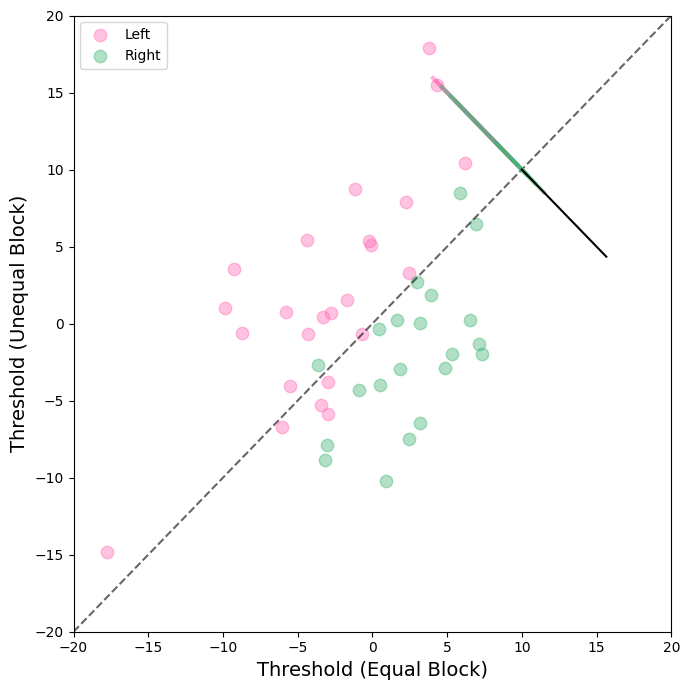

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Example data ---
np.random.seed(0)
eq_left = np.random.normal(-5, 5, 24)
uneq_left = eq_left + np.random.normal(5, 4, 24)
eq_right = np.random.normal(5, 5, 21)
uneq_right = eq_right + np.random.normal(-5, 4, 21)

# df = pd.DataFrame({
#     "Equal": np.concatenate([eq_left, eq_right]),
#     "Unequal": np.concatenate([uneq_left, uneq_right]),
#     "Condition": ["Left"] * len(eq_left) + ["Right"] * len(eq_right)
# })

colors = {"Left": "hotpink", "Right": "mediumseagreen"}

# --- Main scatter ---
fig, ax = plt.subplots(figsize=(7, 7))
for cond, color in colors.items():
    subset = df[df["Condition"] == cond]
    ax.scatter(subset["Equal"], subset["Unequal"], color=color, alpha=0.4, s=80, label=cond)

# --- Axes setup ---
ax.plot([-20, 20], [-20, 20], 'k--', alpha=0.6)
ax.set_xlim(-20, 20)
ax.set_ylim(-20, 20)
ax.set_xlabel("Threshold (Equal Block)", fontsize=14)
ax.set_ylabel("Threshold (Unequal Block)", fontsize=14)
ax.legend()

# --- Compute projections onto perpendicular to y=x ---
v_perp = np.array([1, -1]) / np.sqrt(2)
projections = {
    cond: (df[df["Condition"] == cond][["Equal", "Unequal"]] @ v_perp).values
    for cond in colors
}

# --- Plot histogram along the perpendicular to y=x (top-right corner) ---
x0, y0 = 10, 10
length = 8
# Point *up-left* from diagonal corner
n = np.array([-1, 1]) / np.sqrt(2)

for cond, color in colors.items():
    proj = projections[cond]
    counts, bins = np.histogram(proj, bins=12, range=(-20, 20))
    counts = counts / counts.max() * length  # normalize height
    centers = (bins[:-1] + bins[1:]) / 2

    # For each bin, compute start and end points of histogram bar
    for c, count in zip(centers, counts):
        # move along perpendicular axis (spread bins)
        base = np.array([x0, y0]) - c * n * 0.25
        # extend outward from diagonal
        tip = base + count * n
        ax.plot([base[0], tip[0]], [base[1], tip[1]], color=color, lw=3, alpha=0.5)

# Draw the perpendicular axis
ax.plot([x0, x0 - n[0]*length], [y0, y0 - n[1]*length], color='k', lw=1.5)

plt.tight_layout()
plt.show()


In [25]:
projections

{'Left': array([-9.95536945e+00,  5.78033417e-01, -3.66495854e+00, -3.00609803e+00,
        -7.87088821e+00, -7.69150811e+00, -3.97379141e+00, -4.60513903e+00,
        -1.02449662e+00,  2.06700455e+00, -2.55148975e+00, -3.97775557e+00,
        -7.01532144e+00, -6.93637768e+00, -2.44000823e+00, -2.68049261e+00,
        -5.69778258e-01,  4.80883345e-01,  1.29052698e+00, -9.05315995e+00,
        -2.09401985e+00, -2.29647267e+00,  7.90647219e-03, -5.73460872e+00]),
 'Right': array([ 3.38861014,  1.47335438,  3.17071514,  0.3128221 ,  7.02814875,
         2.39753989,  5.47246934,  5.99852018,  5.172768  ,  4.41673754,
         3.37667433,  6.83107532,  0.98761184,  2.21844163,  7.88068722,
        -0.67387897, -1.82685047,  0.20144179,  4.04443819,  6.56407966,
         0.55309404])}

In [ ]:
np.array([2,3]) *

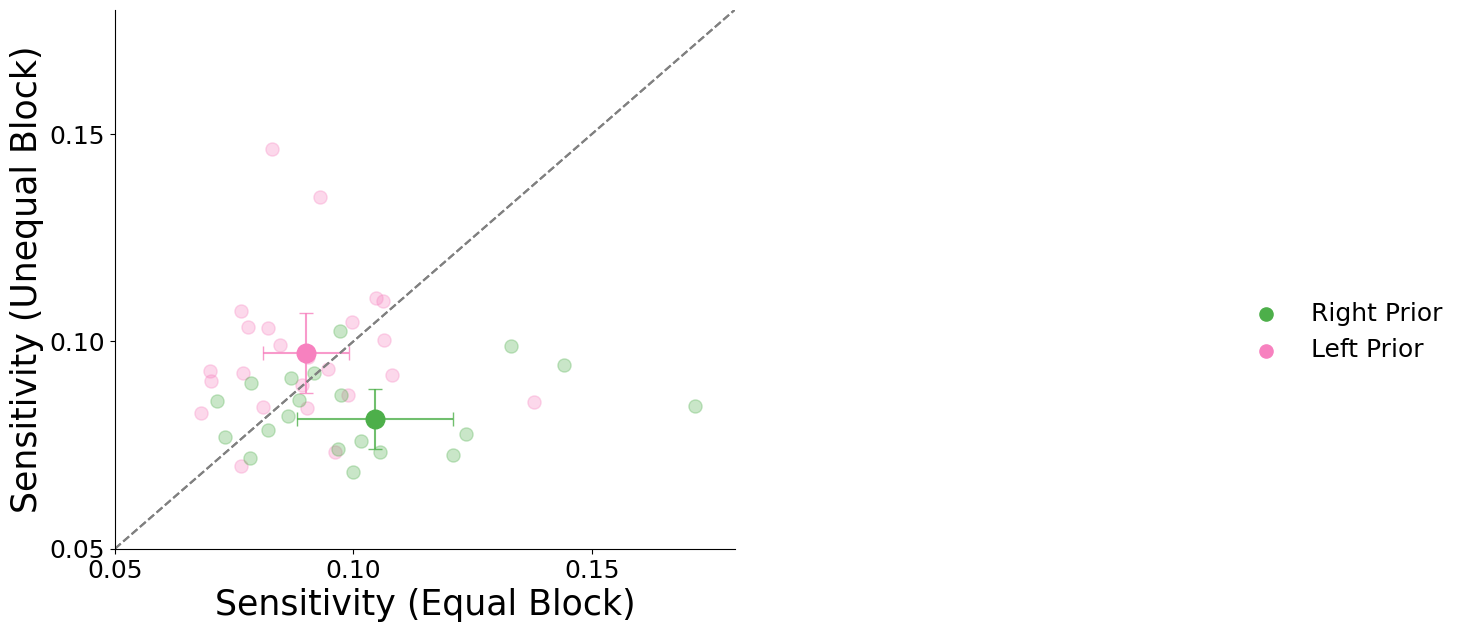

In [41]:
plt.figure(figsize=(8,7))
ax_range = tuple([0.05,0.18])
plt.scatter(eq_left_model['beta'],uneq_left_model['beta'],color=uneq_color["L"], s=90, alpha=0.3)
plt.scatter(eq_right_model['beta'],uneq_right_model['beta'],color=uneq_color["R"], s=90, alpha=0.3)
mean_eq_left = np.mean(eq_left_model['beta'])
mean_uneq_left = np.mean(uneq_left_model['beta'])
sem_eq_left = np.std(eq_left_model['beta']) / np.sqrt(len(eq_left_model))
sem_uneq_left = np.std(uneq_left_model['beta']) / np.sqrt(len(uneq_left_model))

plt.scatter(mean_eq_left, mean_uneq_left, color=uneq_color["L"], s=180)
plt.errorbar(mean_eq_left, mean_uneq_left,
             xerr=sem_eq_left, yerr=sem_uneq_left,
             fmt='o', color=uneq_color["L"], capsize=5, alpha=0.8)

# Right Prior Mean and Error
mean_eq_right = np.mean(eq_right_model['beta'])
mean_uneq_right = np.mean(uneq_right_model['beta'])
sem_eq_right = np.std(eq_right_model['beta']) / np.sqrt(len(eq_right_model))
sem_uneq_right = np.std(uneq_right_model['beta']) / np.sqrt(len(uneq_right_model))

plt.scatter(mean_eq_right, mean_uneq_right, color=uneq_color["R"], s=180)
plt.errorbar(mean_eq_right, mean_uneq_right,
             xerr=sem_eq_right, yerr=sem_uneq_right,
             fmt='o', color=uneq_color["R"], capsize=5, alpha=0.8)


plt.xlim(ax_range)
plt.ylim(ax_range)
plt.plot(ax_range,ax_range,color='gray',linestyle='--')
plt.xticks(np.arange(ax_range[0], ax_range[1]+0.01, 0.05))
plt.yticks(np.arange(ax_range[0], ax_range[1]+0.01, 0.05))

plt.scatter([], [], color=uneq_color["R"], s=90, label="Right Prior")
plt.scatter([], [], color=uneq_color["L"], s=90, label="Left Prior")
plt.xlim(ax_range)
plt.ylim(ax_range)
plt.plot(ax_range,ax_range,color='gray',linestyle='--')

plt.tick_params(axis='both', labelsize=18)
plt.xlabel('Sensitivity (Equal Block)',fontsize=25)
plt.ylabel('Sensitivity (Unequal Block)',fontsize=25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.legend(bbox_to_anchor=(1.78 , .5), loc='upper left', fontsize=18, frameon=False);


## Latency-Probability Plot

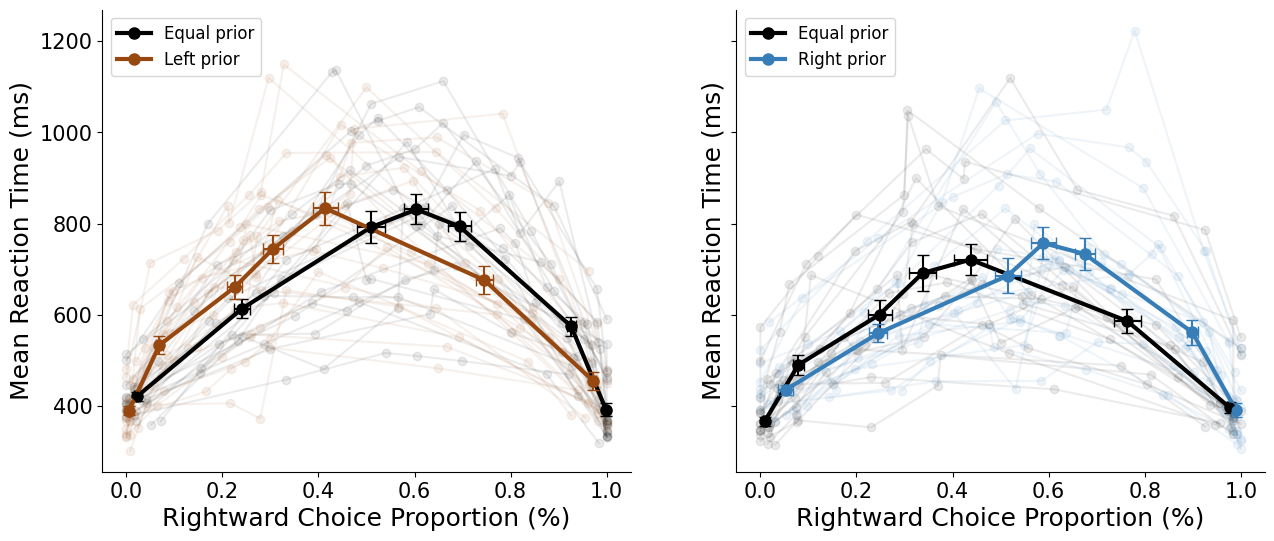

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
eq_color = "black"
uneq_color = {'L':  "#974810", 'R': "#377eb8"}  # Differentiate directions

left_eq_choices, left_eq_rt, right_eq_choices, right_eq_rt = [], [], [], []
left_uneq_choices, left_uneq_rt, right_uneq_choices, right_uneq_rt = [], [], [], []

for session_id in session_metadata["session_id"]:
    session_data = behavior_df[behavior_df.session_id == session_id]

    equal_data = session_data[session_data.prob_toRF == 50]
    unequal_data = session_data[session_data.prob_toRF != 50]

    # Get prior direction safely
    prior_dir = session_data["prior_direction"].iloc[0]
    ax = axs[0] if prior_dir == "L" else axs[1]

    temp_eq_choice, temp_eq_rt = latency_probabilities_plot(equal_data, ax, color=eq_color, alpha=0.08)
    temp_uneq_choice, temp_uneq_rt = latency_probabilities_plot(unequal_data, ax, color=uneq_color.get(prior_dir), alpha=0.08)
    if prior_dir == "L":
        left_eq_choices.append(temp_eq_choice)
        left_eq_rt.append(temp_eq_rt)
        left_uneq_choices.append(temp_uneq_choice)
        left_uneq_rt.append(temp_uneq_rt)
    else:
        right_eq_choices.append(temp_eq_choice)
        right_eq_rt.append(temp_eq_rt)
        right_uneq_choices.append(temp_uneq_choice)
        right_uneq_rt.append(temp_uneq_rt)

kwargs = {'lw': 3, 'markersize': 8}
plot_double_errorbars(np.array(left_eq_choices), np.array(left_eq_rt), axs[0], color=eq_color, label='Equal prior', **kwargs)
plot_double_errorbars(np.array(left_uneq_choices), np.array(left_uneq_rt), axs[0], color=uneq_color['L'], label='Left prior', **kwargs)
plot_double_errorbars(np.array(right_eq_choices), np.array(right_eq_rt), axs[1], color=eq_color, label='Equal prior', **kwargs)
plot_double_errorbars(np.array(right_uneq_choices), np.array(right_uneq_rt), axs[1], color=uneq_color['R'], label='Right prior', **kwargs)
for ax in axs:
    ax.set_xlabel('Rightward Choice Proportion (%)', fontsize=18)
    ax.set_ylabel('Mean Reaction Time (ms)', fontsize=18)
    ax.spines['top'].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=12, loc='upper left')
    ax.tick_params(axis='both', labelsize=15)

## Chronometric functions

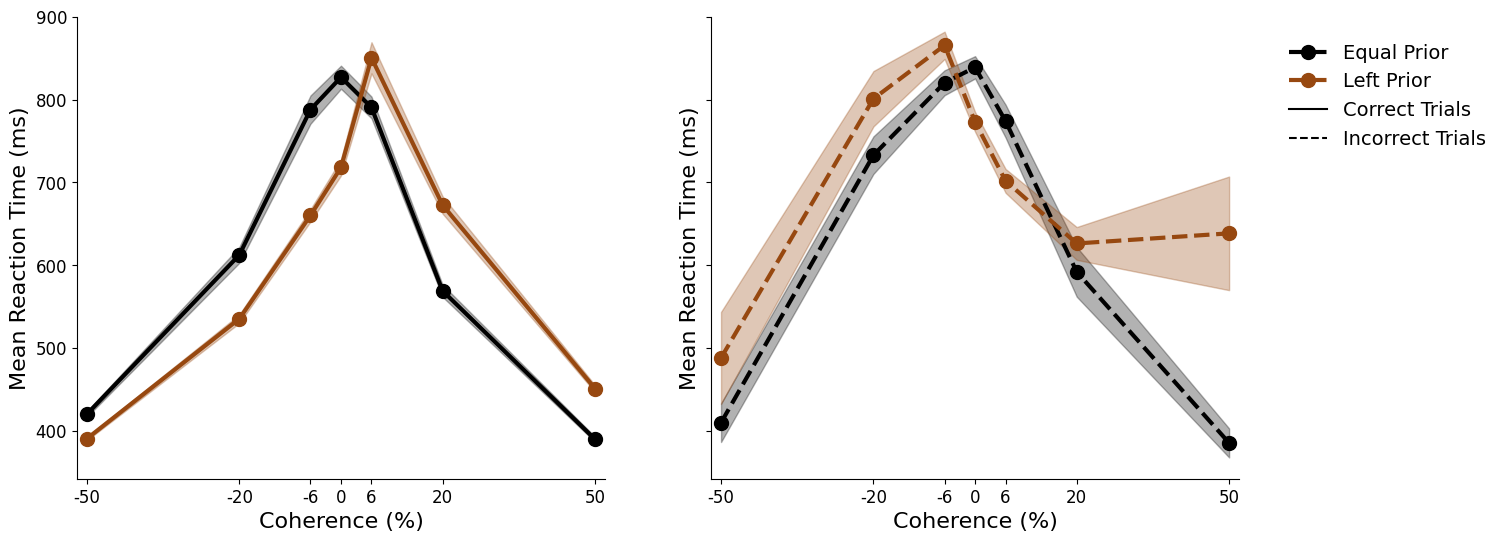

In [14]:

alpha_value = 0.2
fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

eq_color = "black"
uneq_color = {'L':  "#974810", 'R': "#377eb8"}  # Differentiate directions

left_prior_data = behavior_df[behavior_df.prior_direction == "L"]
right_prior_data = behavior_df[behavior_df.prior_direction == "R"]

left_eq_corr_coherences, _, left_eq_corr_rt_mean, _, left_eq_corr_rt_sem = pmf_utils.get_chronometric_data(left_prior_data[left_prior_data.prob_toRF == 50])
left_uneq_corr_coherences, _, left_uneq_corr_rt_mean, _, left_uneq_corr_rt_sem = pmf_utils.get_chronometric_data(left_prior_data[left_prior_data.prob_toRF != 50])

left_eq_incorr_coherences, _, left_eq_incorr_rt_mean, _, left_eq_incorr_rt_sem = pmf_utils.get_chronometric_data(left_prior_data[left_prior_data.prob_toRF == 50], outcome=0)
left_uneq_incorr_coherences, _, left_uneq_incorr_rt_mean, _, left_uneq_incorr_rt_sem = pmf_utils.get_chronometric_data(left_prior_data[left_prior_data.prob_toRF != 50], outcome=0)

axs[0].plot(left_eq_corr_coherences, left_eq_corr_rt_mean, marker="o", linestyle="-",color=eq_color, markersize =10,linewidth=3)
axs[0].plot(left_uneq_corr_coherences, left_uneq_corr_rt_mean, marker="o", linestyle="-", color=uneq_color["L"],markersize =10,linewidth=3)
axs[0].fill_between(left_eq_corr_coherences, left_eq_corr_rt_mean - left_eq_corr_rt_sem, left_eq_corr_rt_mean + left_eq_corr_rt_sem, color=eq_color, alpha=0.3)
axs[0].fill_between(left_uneq_corr_coherences, left_uneq_corr_rt_mean - left_uneq_corr_rt_sem, left_uneq_corr_rt_mean + left_uneq_corr_rt_sem, color=uneq_color["L"], alpha=0.3)


axs[1].plot(left_eq_incorr_coherences, left_eq_incorr_rt_mean, marker="o", linestyle="--",color=eq_color, markersize =10,linewidth=3,label="Equal Prior")
axs[1].plot(left_uneq_incorr_coherences, left_uneq_incorr_rt_mean, marker="o", linestyle="--", color=uneq_color["L"],markersize =10,linewidth=3, label="Left Prior")
axs[1].fill_between(left_eq_incorr_coherences, left_eq_incorr_rt_mean - left_eq_incorr_rt_sem, left_eq_incorr_rt_mean + left_eq_incorr_rt_sem, color=eq_color, alpha=0.3)
axs[1].fill_between(left_uneq_incorr_coherences, left_uneq_incorr_rt_mean - left_uneq_incorr_rt_sem, left_uneq_incorr_rt_mean + left_uneq_incorr_rt_sem, color=uneq_color["L"], alpha=0.3)

axs[1].plot([], [], linestyle="-", color='k', label="Correct Trials")
axs[1].plot([], [], linestyle="--", color='k', label="Incorrect Trials")


for ax in axs:
    ax.set_xticks([-50,-20,-6,0,6,20,50, ax.get_xlim()[1]])
    ax.set_xticklabels([-50,-20,-6,0,6,20,50, ""])
    ax.set_xlim([-52, 52])
    ax.set_ylim([ax.get_ylim()[0], 900])
    ax.tick_params(axis='both', labelsize=12)
    ax.set_xlabel('Coherence (%)',fontsize=16)
    ax.set_ylabel('Mean Reaction Time (ms)',fontsize=16)
    ax.spines['top'].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=14,frameon=False, bbox_to_anchor=(1.5, 0.98))


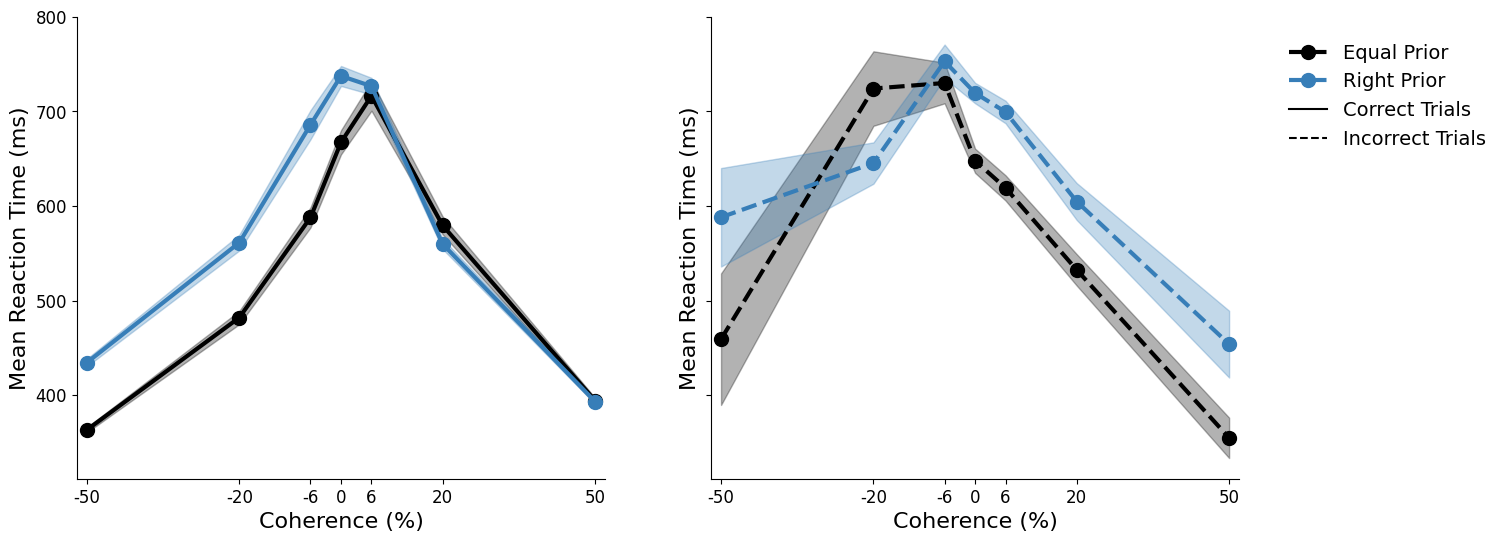

In [15]:

alpha_value = 0.2
fig, axs = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

eq_color = "black"
uneq_color = {'L':  "#974810", 'R': "#377eb8"}  # Differentiate directions

left_prior_data = behavior_df[behavior_df.prior_direction == "L"]
right_prior_data = behavior_df[behavior_df.prior_direction == "R"]

right_eq_corr_coherences, _, right_eq_corr_rt_mean, _, right_eq_corr_rt_sem = pmf_utils.get_chronometric_data(right_prior_data[right_prior_data.prob_toRF == 50])
right_uneq_corr_coherences, _, right_uneq_corr_rt_mean, _, right_uneq_corr_rt_sem = pmf_utils.get_chronometric_data(right_prior_data[right_prior_data.prob_toRF != 50])

right_eq_incorr_coherences, _, right_eq_incorr_rt_mean, _, right_eq_incorr_rt_sem = pmf_utils.get_chronometric_data(right_prior_data[right_prior_data.prob_toRF == 50], outcome=0)
right_uneq_incorr_coherences, _, right_uneq_incorr_rt_mean, _, right_uneq_incorr_rt_sem = pmf_utils.get_chronometric_data(right_prior_data[right_prior_data.prob_toRF != 50], outcome=0)

axs[0].plot(right_eq_corr_coherences, right_eq_corr_rt_mean, marker="o", linestyle="-",color=eq_color, markersize =10,linewidth=3)
axs[0].plot(right_uneq_corr_coherences, right_uneq_corr_rt_mean, marker="o", linestyle="-", color=uneq_color["R"],markersize =10,linewidth=3)
axs[0].fill_between(right_eq_corr_coherences, right_eq_corr_rt_mean - right_eq_corr_rt_sem, right_eq_corr_rt_mean + right_eq_corr_rt_sem, color=eq_color, alpha=0.3)
axs[0].fill_between(right_uneq_corr_coherences, right_uneq_corr_rt_mean - right_uneq_corr_rt_sem, right_uneq_corr_rt_mean + right_uneq_corr_rt_sem, color=uneq_color["R"], alpha=0.3)


axs[1].plot(right_eq_incorr_coherences, right_eq_incorr_rt_mean, marker="o", linestyle="--",color=eq_color, markersize =10,linewidth=3,label="Equal Prior")
axs[1].plot(right_uneq_incorr_coherences, right_uneq_incorr_rt_mean, marker="o", linestyle="--", color=uneq_color["R"],markersize =10,linewidth=3, label="Right Prior")
axs[1].fill_between(right_eq_incorr_coherences, right_eq_incorr_rt_mean - right_eq_incorr_rt_sem, right_eq_incorr_rt_mean + right_eq_incorr_rt_sem, color=eq_color, alpha=0.3)
axs[1].fill_between(right_uneq_incorr_coherences, right_uneq_incorr_rt_mean - right_uneq_incorr_rt_sem, right_uneq_incorr_rt_mean + right_uneq_incorr_rt_sem, color=uneq_color["R"], alpha=0.3)

axs[1].plot([], [], linestyle="-", color='k', label="Correct Trials")
axs[1].plot([], [], linestyle="--", color='k', label="Incorrect Trials")


for ax in axs:
    ax.set_xticks([-50,-20,-6,0,6,20,50, ax.get_xlim()[1]])
    ax.set_xticklabels([-50,-20,-6,0,6,20,50, ""])
    ax.set_xlim([-52, 52])
    ax.set_ylim([ax.get_ylim()[0], 800])
    ax.tick_params(axis='both', labelsize=12)
    ax.set_xlabel('Coherence (%)',fontsize=16)
    ax.set_ylabel('Mean Reaction Time (ms)',fontsize=16)
    ax.spines['top'].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=14,frameon=False, bbox_to_anchor=(1.5, 0.98))


## Half-Psych

In [16]:
def get_half_psych(data, model_type='logit_4', exclude_zero=False):
    all_coh = np.sort(np.abs(data['signed_coherence']).unique())

    if exclude_zero:
        all_coh = all_coh[all_coh != 0]

    coherences, left_accuracies, right_accuracies = [], [], []
    left_trials, right_trials = [], []
    for coh in all_coh:
        coherences.append(coh)
        left_trials.append(np.sum(data['signed_coherence'] == -coh))
        right_trials.append(np.sum(data['signed_coherence'] == coh))
        left_accuracies.append(np.sum(data['choice'][data['signed_coherence'] == -coh] == 0) / left_trials[-1])
        right_accuracies.append(np.sum(data['choice'][data['signed_coherence'] == coh] == 1) / right_trials[-1])

    coherences = np.array(coherences)
    left_accuracies = np.array(left_accuracies)
    right_accuracies = np.array(right_accuracies)
    left_trials = np.array(left_trials)
    right_trials = np.array(right_trials)

    params = {
        "mean_lims": (-50, 50),
        "var_lims": (1e-5, 30),
        "lapse_rate_lims": (1e-5, 0.4),
        "guess_rate_lims": (1e-5, 1),
    }

    # fit psychometric function
    x_model = np.linspace(0, max(coherences))
    left_model = pmf_utils.fit_psychometric_function(coherences, left_accuracies, trial_counts=left_trials, model_type=model_type, **params)
    left_hat = left_model.predict(x_model)
    right_model = pmf_utils.fit_psychometric_function(coherences, right_accuracies, trial_counts=right_trials, model_type=model_type, **params)
    right_hat = right_model.predict(x_model)

    return coherences, left_accuracies, right_accuracies, x_model, left_hat, left_model, right_hat, right_model

In [17]:
# import matplotlib.pyplot as plt

# alpha_value = 1
# plt.ion()  # Turn on interactive mode

# model_type='logit_3'

# eq_color = "black"
# uneq_color = {'L':  "#974810", 'R': "#377eb8"}

# # for session_id in session_metadata["session_id"]:
# def plot_session_psych(session_id):


#     fig, axs = plt.subplots(1, 3, figsize=(24,7), sharey=True, sharex=True)

#     session_data = behavior_df[behavior_df.session_id == session_id]
#     equal_data = session_data[session_data.prob_toRF == 50]
#     unequal_data = session_data[session_data.prob_toRF != 50]

#     prior_dir = session_data["prior_direction"].iloc[0]
#     color = uneq_color.get(prior_dir)

#     eq_coherences, eq_left_choices, eq_right_choices, eq_x_model, eq_left_hat, eq_left_model, eq_right_hat, eq_right_model = get_half_psych(equal_data, model_type=model_type)
#     uneq_coherences, uneq_left_choices, uneq_right_choices, uneq_x_model, uneq_left_hat, uneq_left_model, uneq_right_hat, uneq_right_model = get_half_psych(unequal_data, model_type=model_type)

#     axs[0].plot(eq_coherences, eq_right_choices, "o", color=eq_color, alpha=alpha_value)
#     axs[0].plot(eq_x_model, eq_right_hat, linestyle="-", color=eq_color, alpha=alpha_value)
#     axs[0].plot(uneq_coherences, uneq_right_choices, "o", color=color, alpha=alpha_value)
#     axs[0].plot(uneq_x_model, uneq_right_hat, linestyle="-", color=color, alpha=alpha_value)

#     axs[1].plot(eq_coherences, eq_left_choices, "o", color=eq_color, alpha=alpha_value)
#     axs[1].plot(eq_x_model, eq_left_hat, linestyle="-", color=eq_color, alpha=alpha_value)
#     axs[1].plot(uneq_coherences, uneq_left_choices, "o", color=color, alpha=alpha_value)
#     axs[1].plot(uneq_x_model, uneq_left_hat, linestyle="-", color=color, alpha=alpha_value)

#     axs[0].set_xlabel("Right Coherence", fontsize=25)
#     axs[1].set_xlabel("Left Coherence", fontsize=25)
#     axs[0].set_ylabel("Proportion of Correct Choices", fontsize=25)
#     axs[1].set_ylabel("Proportion of Correct Choices", fontsize=25)

#     # add model parameters to the third subplot as a table
#     param_table_data_right = [
#         ["Right Parameter", "Equal Block", "Unequal Block"],
#         ["Alpha (mean)", f"{eq_right_model.coefs_['mean']:.2f}", f"{uneq_right_model.coefs_['mean']:.2f}"],
#         ["Beta (var)", f"{eq_right_model.coefs_['var']:.2f}", f"{uneq_right_model.coefs_['var']:.2f}"],
#     ]
#     if model_type in ['logit_3', 'logit_4']:
#         param_table_data_right.append(["Lapse Rate", f"{eq_right_model.coefs_['lapse_rate']:.2f}", f"{uneq_right_model.coefs_['lapse_rate']:.2f}"])
#     if model_type in ['logit_4']:
#         param_table_data_right.append(["Guess Rate", f"{eq_right_model.coefs_['guess_rate']:.2f}", f"{uneq_right_model.coefs_['guess_rate']:.2f}"])

#     param_table_data_left = [
#         ["Left Parameter", "Equal Block", "Unequal Block"],
#         ["Alpha (mean)", f"{eq_left_model.coefs_['mean']:.2f}", f"{uneq_left_model.coefs_['mean']:.2f}"],
#         ["Beta (var)", f"{eq_left_model.coefs_['var']:.2f}", f"{uneq_left_model.coefs_['var']:.2f}"],
#         ]
#     if model_type in ['logit_3', 'logit_4']:
#         param_table_data_left.append(["Lapse Rate", f"{eq_left_model.coefs_['lapse_rate']:.2f}", f"{uneq_left_model.coefs_['lapse_rate']:.2f}"])
#     if model_type in ['logit_4']:
#         param_table_data_left.append(["Guess Rate", f"{eq_left_model.coefs_['guess_rate']:.2f}", f"{uneq_left_model.coefs_['guess_rate']:.2f}"])

#     axs[2].axis('off')
#     table_R = axs[2].table(cellText=param_table_data_right, colWidths=[0.35, 0.3, 0.35], cellLoc='center', loc='top')
#     table_R.auto_set_font_size(False)
#     table_R.set_fontsize(12)
#     table_R.scale(1, 1.5)


#     table_L = axs[2].table(cellText=param_table_data_left, colWidths=[0.35, 0.3, 0.35], cellLoc='center', loc='center')
#     table_L.auto_set_font_size(False)
#     table_L.set_fontsize(12)
#     table_L.scale(1, 1.5)


#     for ax in axs:
#         ax.set_xticks([0,6,20,50])
#         ax.tick_params(axis='both', labelsize=18)
#         ax.spines['top'].set_visible(False)
#         ax.spines["right"].set_visible(False)
#         ax.set_ylim([0, 1])

#     fig.suptitle(f"Session {session_id}", fontsize=20)
#     plt.plot()
#     plt.pause(0.1)  # Pause to update the plots


# for session_id in session_metadata['session_id']:
#     plot_session_psych(session_id)

#     # command = input("Press Anything to continue to the next session, or type 'x' to exit: ")
#     # if command.strip().lower() == "c":
#     #     break
#     # plt.close(fig)

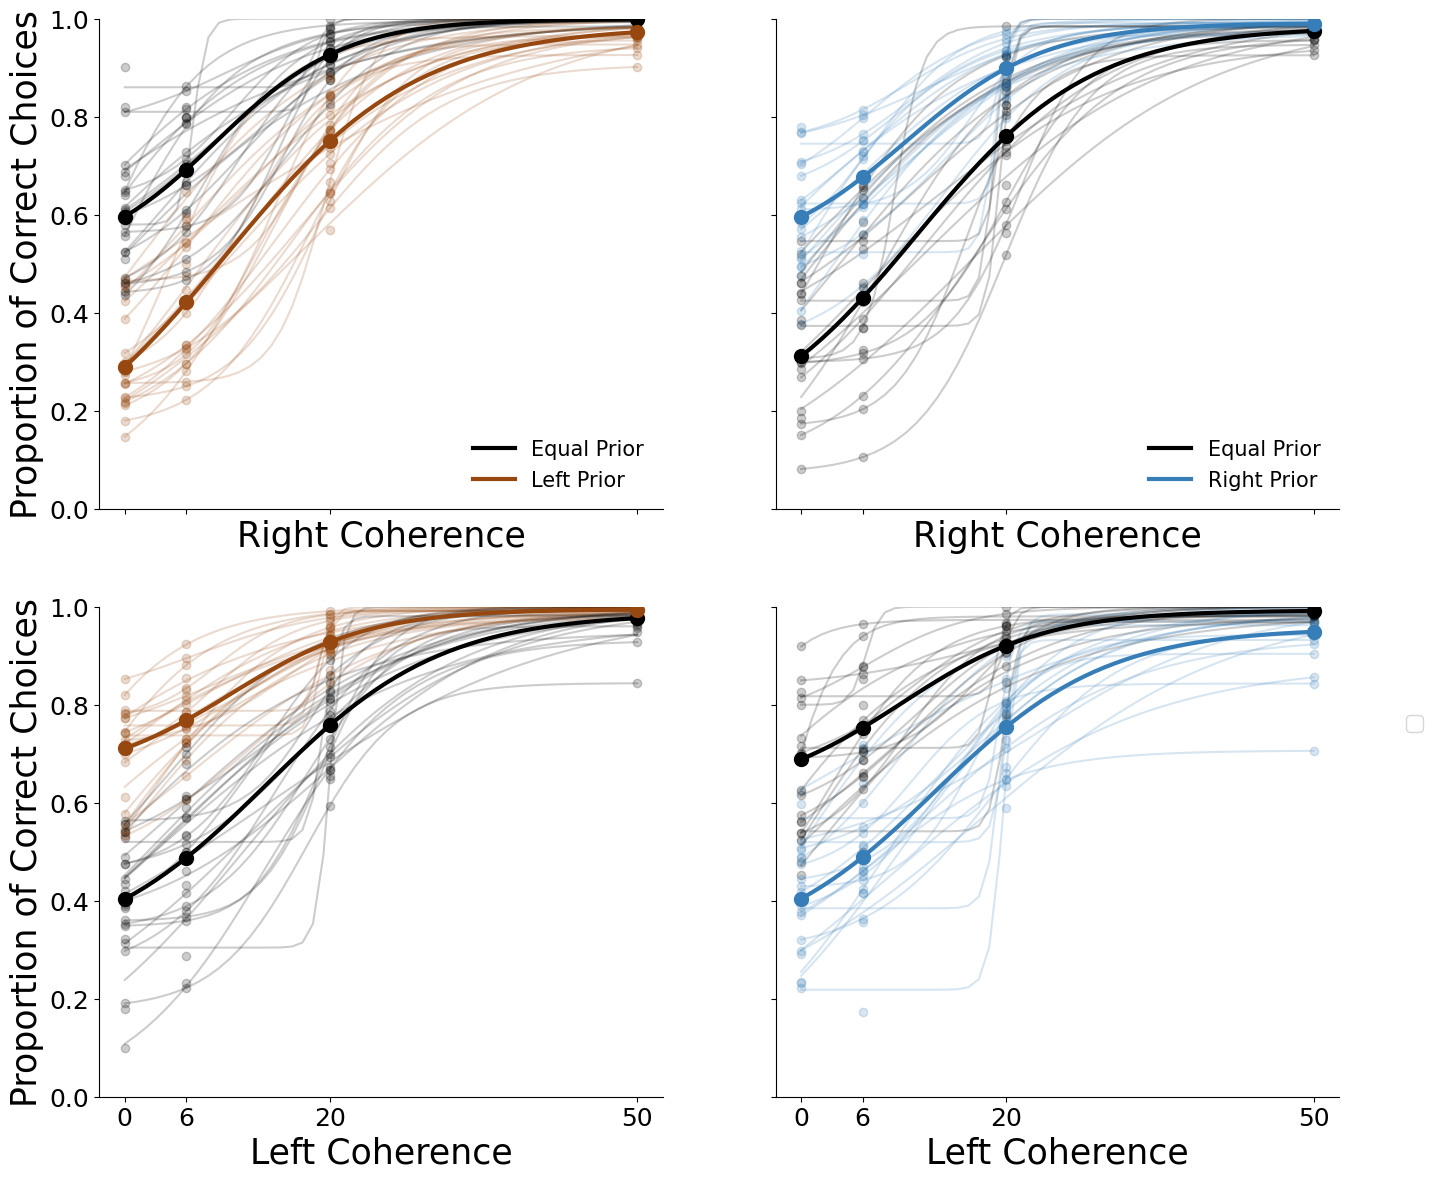

In [18]:
alpha_value = 0.2
fig, axs = plt.subplots(2, 2, figsize=(16,14), sharey=True, sharex=True)

model_type='logit_4'

eq_color = "black"
uneq_color = {'L':  "#974810", 'R': "#377eb8"}  # Differentiate directions

eq_L_prior_L_dir_model, uneq_L_prior_L_dir_model = {'alpha': [], 'beta': [], 'lapse_rate': [], 'guess_rate': []}, {'alpha': [], 'beta': [], 'lapse_rate': [], 'guess_rate': []}
eq_L_prior_R_dir_model, uneq_L_prior_R_dir_model = {'alpha': [], 'beta': [], 'lapse_rate': [], 'guess_rate': []}, {'alpha': [], 'beta': [], 'lapse_rate': [], 'guess_rate': []}
eq_R_prior_L_dir_model, uneq_R_prior_L_dir_model = {'alpha': [], 'beta': [], 'lapse_rate': [], 'guess_rate': []}, {'alpha': [], 'beta': [], 'lapse_rate': [], 'guess_rate': []}
eq_R_prior_R_dir_model, uneq_R_prior_R_dir_model = {'alpha': [], 'beta': [], 'lapse_rate': [], 'guess_rate': []}, {'alpha': [], 'beta': [], 'lapse_rate': [], 'guess_rate': []}

def store_model_params(target_dict, model, stim_dir):
    if model is None:
        return
    target_dict[stim_dir]['alpha'].append(model.coefs_.get("mean"))
    target_dict[stim_dir]['beta'].append(model.coefs_.get("var"))
    target_dict[stim_dir]['lapse_rate'].append(model.coefs_.get("lapse_rate"))
    target_dict[stim_dir]['guess_rate'].append(model.coefs_.get("guess_rate"))


for session_id in session_metadata["session_id"]:
    session_data = behavior_df[behavior_df.session_id == session_id]

    if session_data.empty:
        continue  # Skip if no data

    equal_data = session_data[session_data.prob_toRF == 50]
    unequal_data = session_data[session_data.prob_toRF != 50]

    # Get prior direction safely
    prior_dir = session_data["prior_direction"].iloc[0]
    color = uneq_color.get(prior_dir)

    eq_coherences, eq_left_choices, eq_right_choices, eq_x_model, eq_left_hat, eq_left_model, eq_right_hat, eq_right_model = get_half_psych(equal_data, model_type=model_type)
    uneq_coherences, uneq_left_choices, uneq_right_choices, uneq_x_model, uneq_left_hat, uneq_left_model, uneq_right_hat, uneq_right_model = get_half_psych(unequal_data, model_type=model_type)

    if prior_dir == "L":
        eq_L_prior_L_dir_model['alpha'].append(eq_left_model.coefs_['mean'])
        eq_L_prior_L_dir_model['beta'].append(eq_left_model.coefs_['var'])
        eq_L_prior_L_dir_model['lapse_rate'].append(eq_left_model.coefs_['lapse_rate'])
        eq_L_prior_L_dir_model['guess_rate'].append(eq_left_model.coefs_['guess_rate'])
        eq_L_prior_R_dir_model['alpha'].append(eq_right_model.coefs_['mean'])
        eq_L_prior_R_dir_model['beta'].append(eq_right_model.coefs_['var'])
        eq_L_prior_R_dir_model['lapse_rate'].append(eq_right_model.coefs_['lapse_rate'])
        eq_L_prior_R_dir_model['guess_rate'].append(eq_right_model.coefs_['guess_rate'])
        uneq_L_prior_L_dir_model['alpha'].append(uneq_left_model.coefs_['mean'])
        uneq_L_prior_L_dir_model['beta'].append(uneq_left_model.coefs_['var'])
        uneq_L_prior_L_dir_model['lapse_rate'].append(uneq_left_model.coefs_['lapse_rate'])
        uneq_L_prior_L_dir_model['guess_rate'].append(uneq_left_model.coefs_['guess_rate'])
        uneq_L_prior_R_dir_model['alpha'].append(uneq_right_model.coefs_['mean'])
        uneq_L_prior_R_dir_model['beta'].append(uneq_right_model.coefs_['var'])
        uneq_L_prior_R_dir_model['lapse_rate'].append(uneq_right_model.coefs_['lapse_rate'])
        uneq_L_prior_R_dir_model['guess_rate'].append(uneq_right_model.coefs_['guess_rate'])
        plot_col = 0
    elif prior_dir == 'R':
        eq_R_prior_L_dir_model['alpha'].append(eq_left_model.coefs_['mean'])
        eq_R_prior_L_dir_model['beta'].append(eq_left_model.coefs_['var'])
        eq_R_prior_L_dir_model['lapse_rate'].append(eq_left_model.coefs_['lapse_rate'])
        eq_R_prior_L_dir_model['guess_rate'].append(eq_left_model.coefs_['guess_rate'])
        eq_R_prior_R_dir_model['alpha'].append(eq_right_model.coefs_['mean'])
        eq_R_prior_R_dir_model['beta'].append(eq_right_model.coefs_['var'])
        eq_R_prior_R_dir_model['lapse_rate'].append(eq_right_model.coefs_['lapse_rate'])
        eq_R_prior_R_dir_model['guess_rate'].append(eq_right_model.coefs_['guess_rate'])
        uneq_R_prior_L_dir_model['alpha'].append(uneq_left_model.coefs_['mean'])
        uneq_R_prior_L_dir_model['beta'].append(uneq_left_model.coefs_['var'])
        uneq_R_prior_L_dir_model['lapse_rate'].append(uneq_left_model.coefs_['lapse_rate'])
        uneq_R_prior_L_dir_model['guess_rate'].append(uneq_left_model.coefs_['guess_rate'])
        uneq_R_prior_R_dir_model['alpha'].append(uneq_right_model.coefs_['mean'])
        uneq_R_prior_R_dir_model['beta'].append(uneq_right_model.coefs_['var'])
        uneq_R_prior_R_dir_model['lapse_rate'].append(uneq_right_model.coefs_['lapse_rate'])
        uneq_R_prior_R_dir_model['guess_rate'].append(uneq_right_model.coefs_['guess_rate'])
        plot_col = 1

    axs[0,plot_col].plot(eq_coherences, eq_right_choices, "o", color=eq_color, alpha=alpha_value)
    axs[0,plot_col].plot(eq_x_model, eq_right_hat, linestyle="-", color=eq_color, alpha=alpha_value)
    axs[0,plot_col].plot(uneq_coherences, uneq_right_choices, "o", color=color, alpha=alpha_value)
    axs[0,plot_col].plot(uneq_x_model, uneq_right_hat, linestyle="-", color=color, alpha=alpha_value)
    axs[1,plot_col].plot(eq_coherences, eq_left_choices, "o", color=eq_color, alpha=alpha_value)
    axs[1,plot_col].plot(eq_x_model, eq_left_hat, linestyle="-", color=eq_color, alpha=alpha_value)
    axs[1,plot_col].plot(uneq_coherences, uneq_left_choices, "o", color=color, alpha=alpha_value)
    axs[1,plot_col].plot(uneq_x_model, uneq_left_hat, linestyle="-", color=color, alpha=alpha_value)




left_prior_data = behavior_df[behavior_df.prior_direction == "L"]
right_prior_data = behavior_df[behavior_df.prior_direction == "R"]

left_prior_eq_coherences, left_prior_eq_left_choices, left_prior_eq_right_choices, left_prior_eq_x_model, left_prior_eq_left_hat, left_prior_eq_left_model, left_prior_eq_right_hat, left_prior_eq_right_model = get_half_psych(left_prior_data[left_prior_data.prob_toRF == 50], model_type=model_type)
left_prior_uneq_coherences, left_prior_uneq_left_choices, left_prior_uneq_right_choices, left_prior_uneq_x_model, left_prior_uneq_left_hat, left_prior_uneq_left_model, left_prior_uneq_right_hat, left_prior_uneq_right_model = get_half_psych(left_prior_data[left_prior_data.prob_toRF != 50], model_type=model_type)
axs[0,0].plot(left_prior_eq_coherences, left_prior_eq_right_choices, "o", color=eq_color, markersize =10)
axs[0,0].plot(left_prior_eq_x_model, left_prior_eq_right_hat, linestyle="-", color=eq_color,linewidth=3, label="Equal Prior")
axs[0,0].plot(left_prior_uneq_coherences, left_prior_uneq_right_choices, "o", color=uneq_color["L"], markersize =10)
axs[0,0].plot(left_prior_uneq_x_model, left_prior_uneq_right_hat, linestyle="-", color=uneq_color["L"],linewidth=3, label="Left Prior")
axs[1,0].plot(left_prior_eq_coherences, left_prior_eq_left_choices, "o", color=eq_color, markersize =10)
axs[1,0].plot(left_prior_eq_x_model, left_prior_eq_left_hat, linestyle="-", color=eq_color,linewidth=3)
axs[1,0].plot(left_prior_uneq_coherences, left_prior_uneq_left_choices, "o", color=uneq_color["L"], markersize =10)
axs[1,0].plot(left_prior_uneq_x_model, left_prior_uneq_left_hat, linestyle="-", color=uneq_color["L"],linewidth=3)

right_prior_eq_coherences, right_prior_eq_left_choices, right_prior_eq_right_choices, right_prior_eq_x_model, right_prior_eq_left_hat, right_prior_eq_left_model, right_prior_eq_right_hat, right_prior_eq_right_model = get_half_psych(right_prior_data[right_prior_data.prob_toRF == 50], model_type=model_type)
right_prior_uneq_coherences, right_prior_uneq_left_choices, right_prior_uneq_right_choices, right_prior_uneq_x_model, right_prior_uneq_left_hat, right_prior_uneq_left_model, right_prior_uneq_right_hat, right_prior_uneq_right_model = get_half_psych(right_prior_data[right_prior_data.prob_toRF != 50], model_type=model_type)

axs[0,1].plot(right_prior_eq_coherences, right_prior_eq_right_choices, "o", color=eq_color, markersize =10)
axs[0,1].plot(right_prior_eq_x_model, right_prior_eq_right_hat, linestyle="-", color=eq_color,linewidth=3, label="Equal Prior")
axs[0,1].plot(right_prior_uneq_coherences, right_prior_uneq_right_choices, "o", color=uneq_color["R"], markersize =10)
axs[0,1].plot(right_prior_uneq_x_model, right_prior_uneq_right_hat, linestyle="-", color=uneq_color["R"],linewidth=3, label="Right Prior")
axs[1,1].plot(right_prior_eq_coherences, right_prior_eq_left_choices, "o", color=eq_color, markersize =10)
axs[1,1].plot(right_prior_eq_x_model, right_prior_eq_left_hat, linestyle="-", color=eq_color,linewidth=3)
axs[1,1].plot(right_prior_uneq_coherences, right_prior_uneq_left_choices, "o", color=uneq_color["R"], markersize =10)
axs[1,1].plot(right_prior_uneq_x_model, right_prior_uneq_left_hat, linestyle="-", color=uneq_color["R"],linewidth=3)


# axs[0,0].set_title('Leftward choices', fontsize=28, pad=30)
# axs[1,0].set_title('Rightward choices', fontsize=28, pad=30)

axs[0,0].set_xlabel(f"Right Coherence",fontsize=25)
axs[1,0].set_xlabel("Left Coherence",fontsize=25)
axs[0,1].set_xlabel(f"Right Coherence",fontsize=25)
axs[1,1].set_xlabel("Left Coherence",fontsize=25)
axs[0,0].set_ylabel(f"Proportion of Correct Choices",fontsize=25)
axs[1,0].set_ylabel("Proportion of Correct Choices",fontsize=25)

for ax in axs:
    for axx in ax:
        axx.set_xticks([0,6,20,50])
        axx.tick_params(axis='both', labelsize=18)
        axx.spines['top'].set_visible(False)
        axx.spines["right"].set_visible(False)

        axx.set_ylim([0, 1])
        axx.legend(fontsize=15, frameon=False)

    # ax.scatter([], [], color=uneq_color["R"], s=90, label="Right Prior")
    # ax.scatter([], [], color=uneq_color["L"], s=90, label="Left Prior")

plt.legend(bbox_to_anchor=(1.1 , 0.8), loc='upper left', fontsize=15, frameon=True);


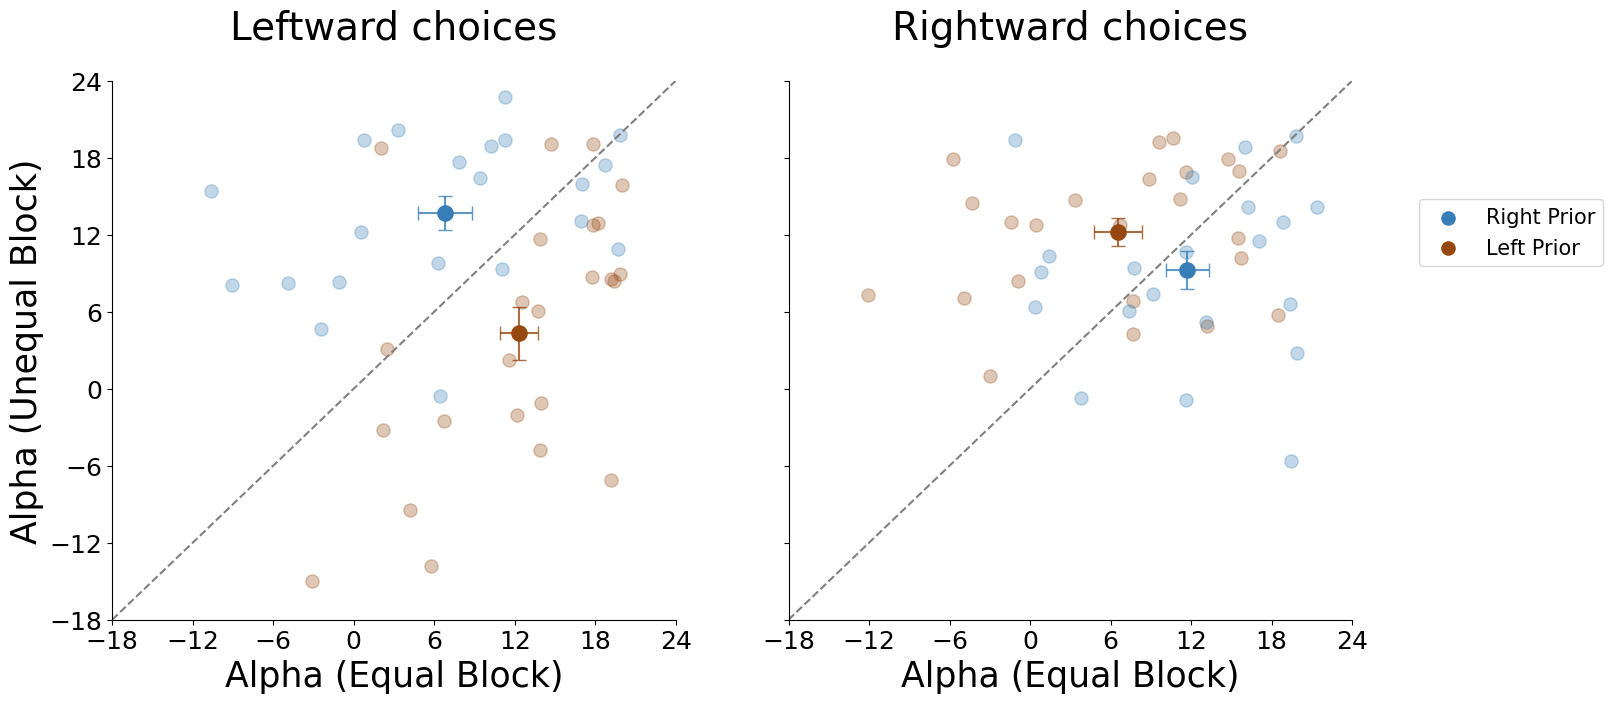

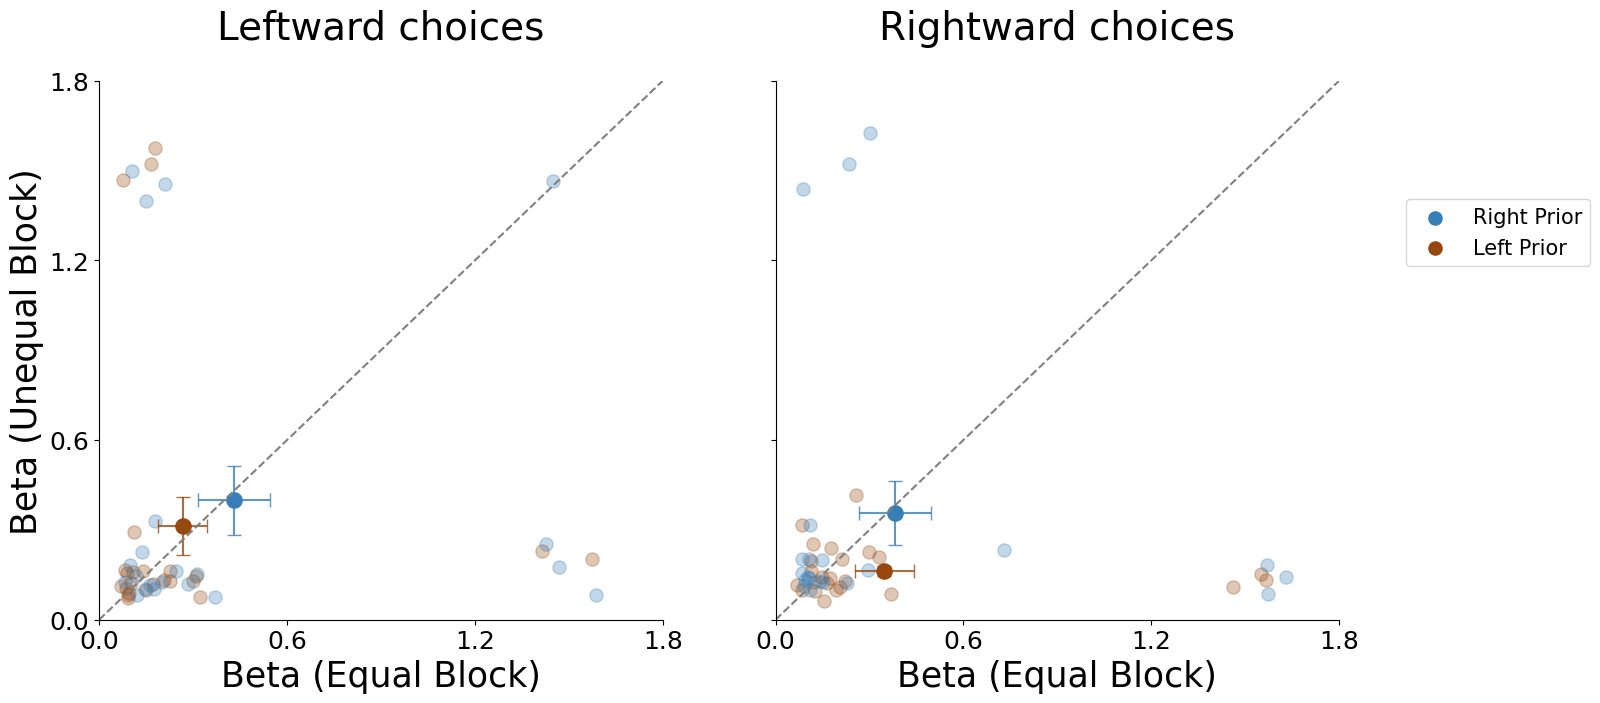

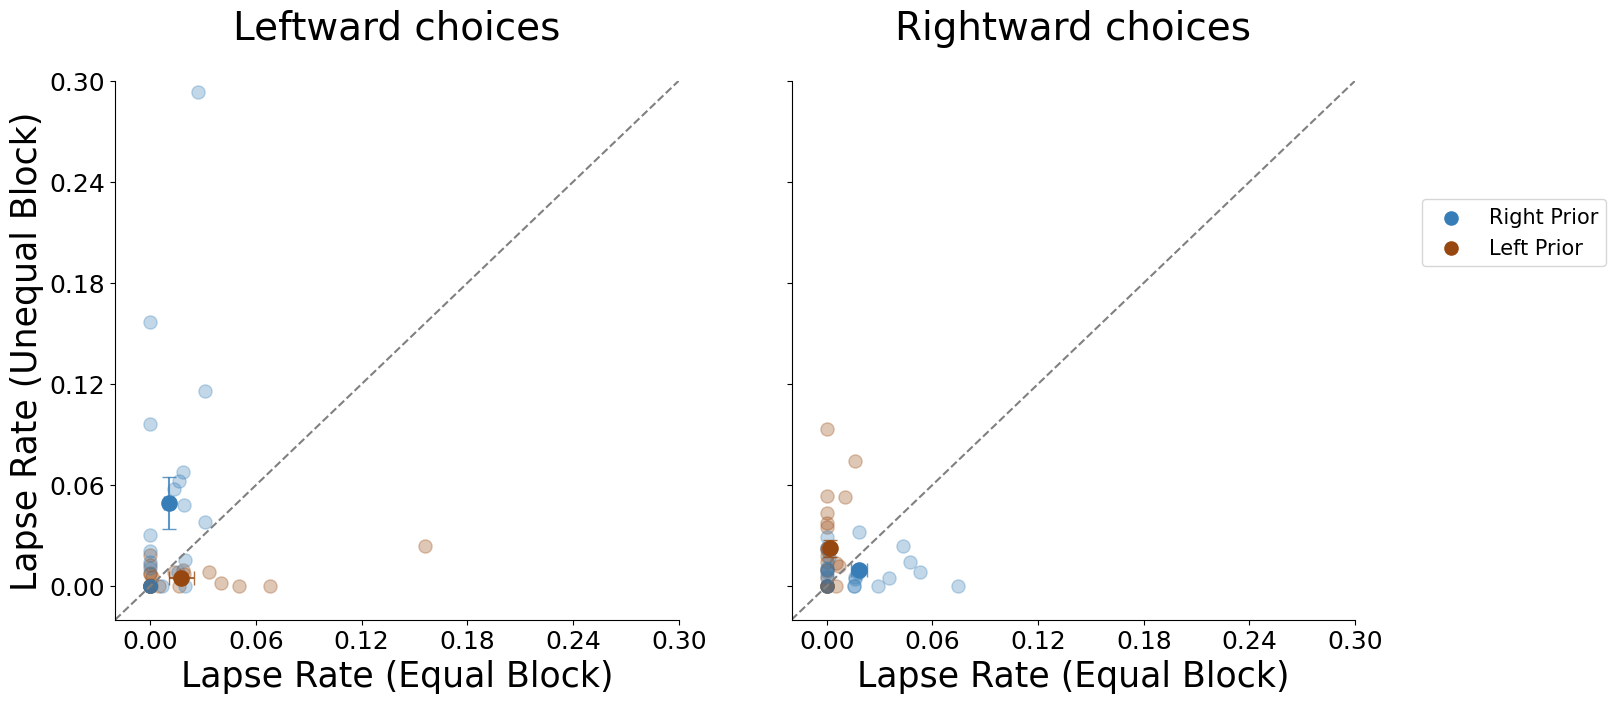

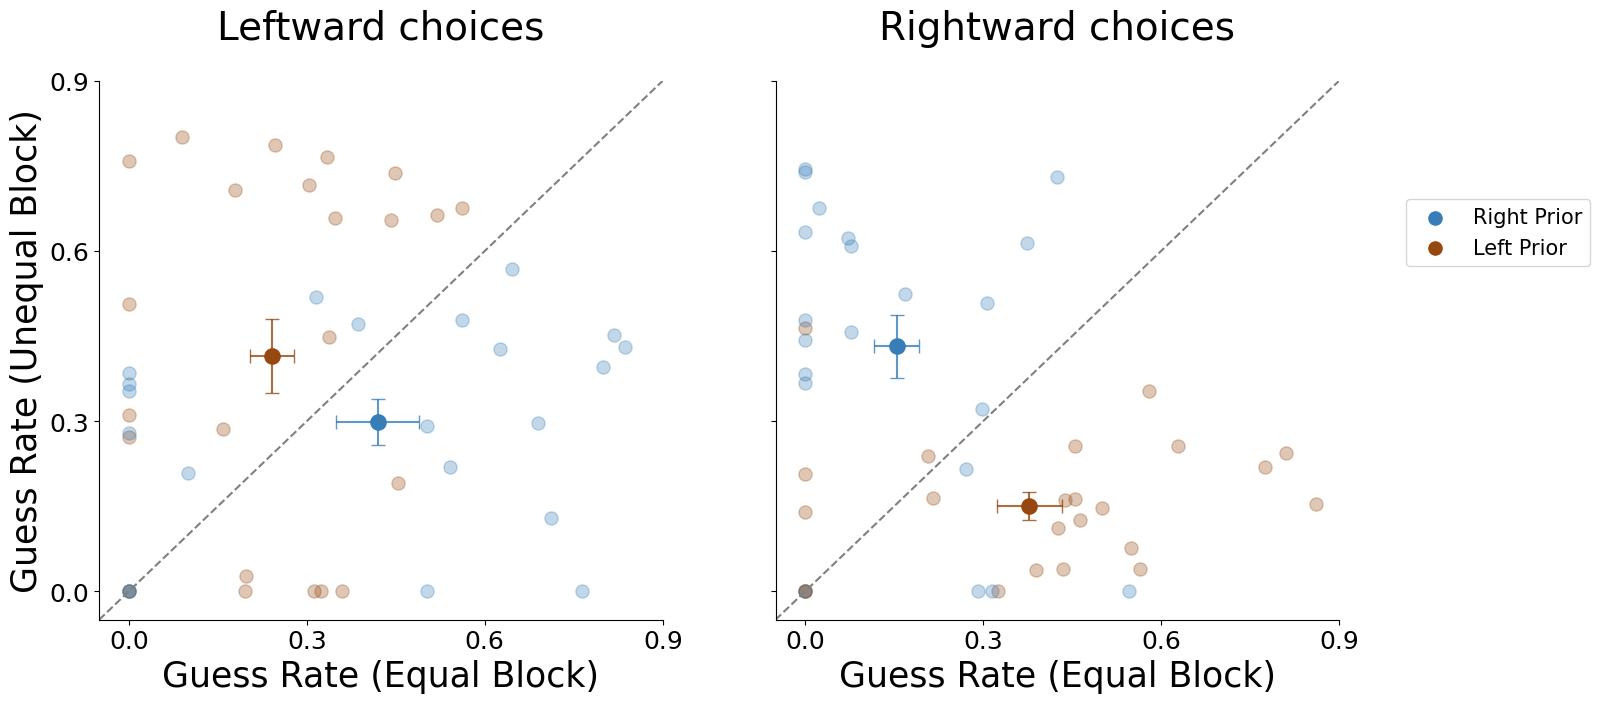

In [19]:
from scipy import stats
def scatter_params(param, lim=None, alpha_value=0.3, marker_size=90):
    fig, axs = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
    axs[0].scatter(eq_L_prior_L_dir_model[param], uneq_L_prior_L_dir_model[param], color=uneq_color['L'], alpha=alpha_value, s=marker_size)
    axs[0].scatter(eq_R_prior_L_dir_model[param], uneq_R_prior_L_dir_model[param], color=uneq_color['R'], alpha=alpha_value, s=marker_size)
    axs[1].scatter(eq_L_prior_R_dir_model[param], uneq_L_prior_R_dir_model[param], color=uneq_color['L'], alpha=alpha_value, s=marker_size)
    axs[1].scatter(eq_R_prior_R_dir_model[param], uneq_R_prior_R_dir_model[param], color=uneq_color['R'], alpha=alpha_value, s=marker_size)

    axs[0].scatter(np.mean(eq_L_prior_L_dir_model[param]), np.mean(uneq_L_prior_L_dir_model[param]), color=uneq_color['L'], s=120)
    axs[0].scatter(np.mean(eq_R_prior_L_dir_model[param]), np.mean(uneq_R_prior_L_dir_model[param]), color=uneq_color['R'], s=120)
    axs[0].errorbar(np.mean(eq_L_prior_L_dir_model[param]), np.mean(uneq_L_prior_L_dir_model[param]), xerr=stats.sem(eq_L_prior_L_dir_model[param]), yerr=stats.sem(uneq_L_prior_L_dir_model[param]), fmt='o', color=uneq_color['L'], capsize=5, alpha=0.8)
    axs[0].errorbar(np.mean(eq_R_prior_L_dir_model[param]), np.mean(uneq_R_prior_L_dir_model[param]), xerr=stats.sem(eq_R_prior_L_dir_model[param]), yerr=stats.sem(uneq_R_prior_L_dir_model[param]), fmt='o', color=uneq_color['R'], capsize=5, alpha=0.8)
    axs[1].scatter(np.mean(eq_L_prior_R_dir_model[param]), np.mean(uneq_L_prior_R_dir_model[param]), color=uneq_color['L'], s=120)
    axs[1].scatter(np.mean(eq_R_prior_R_dir_model[param]), np.mean(uneq_R_prior_R_dir_model[param]), color=uneq_color['R'], s=120)
    axs[1].errorbar(np.mean(eq_L_prior_R_dir_model[param]), np.mean(uneq_L_prior_R_dir_model[param]), xerr=stats.sem(eq_L_prior_R_dir_model[param]), yerr=stats.sem(uneq_L_prior_R_dir_model[param]), fmt='o', color=uneq_color['L'], capsize=5, alpha=0.8)
    axs[1].errorbar(np.mean(eq_R_prior_R_dir_model[param]), np.mean(uneq_R_prior_R_dir_model[param]), xerr=stats.sem(eq_R_prior_R_dir_model[param]), yerr=stats.sem(uneq_R_prior_R_dir_model[param]), fmt='o', color=uneq_color['R'], capsize=5, alpha=0.8)


    axs[0].set_title('Leftward choices', fontsize=28, pad=30)
    axs[1].set_title('Rightward choices', fontsize=28, pad=30)

    axs[0].set_xlabel(f"{param.title().replace('_', ' ')} (Equal Block)",fontsize=25)
    axs[1].set_xlabel(f"{param.title().replace('_', ' ')} (Equal Block)",fontsize=25)
    axs[0].set_ylabel(f"{param.title().replace('_', ' ')} (Unequal Block)",fontsize=25)

    for ax in axs:
        if lim:
            ax.set_xlim(lim)
            ax.set_ylim(lim)
            ax.plot([lim[0], lim[1]], [lim[0], lim[1]], linestyle='--', color ='gray')

        ax.tick_params(axis='both', labelsize=18)
        ax.spines['top'].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.scatter([], [], color=uneq_color["R"], s=90, label="Right Prior")
        ax.scatter([], [], color=uneq_color["L"], s=90, label="Left Prior")

    plt.legend(bbox_to_anchor=(1.1 , 0.8), loc='upper left', fontsize=15, frameon=True);

    return fig, axs




fig, axs = scatter_params('alpha', lim=(-18, 24))
axs[0].set_xticks(np.arange(-18, 25, 6));
axs[1].set_xticks(np.arange(-18, 25, 6));
axs[1].set_yticks(np.arange(-18, 25, 6));
fig, axs = scatter_params('beta', lim=(0,1.8))
axs[0].set_xticks(np.arange(0, 1.9, 0.6));
axs[1].set_xticks(np.arange(0, 1.9, 0.6));
axs[1].set_yticks(np.arange(0, 1.9, 0.6));
fig, axs = scatter_params('lapse_rate', lim=(-0.02,0.3))
axs[0].set_xticks(np.arange(0, 0.31, 0.06));
axs[1].set_xticks(np.arange(0, 0.31, 0.06));
axs[1].set_yticks(np.arange(0, 0.31, 0.06));
fig, axs = scatter_params('guess_rate',lim=(-0.05,0.9))
axs[0].set_xticks(np.arange(0, 0.91, 0.30));
axs[1].set_xticks(np.arange(0, 0.91, 0.30));
axs[1].set_yticks(np.arange(0, 0.91, 0.30));

## Rolling Psych

In [20]:
import matplotlib.pyplot as plt

rolling_window = 80
model_type = "logit_3"

session_rolling_coefs = {'left_prior':{}, 'right_prior': {}}

def add_coefs_to_dict(coefs_dict, model):
    coefs_dict['alpha'].append(model.coefs_['mean'])
    coefs_dict['beta'].append(model.coefs_['var'])
    coefs_dict['lapse_rate'].append(model.coefs_['lapse_rate'])


for session_id in session_metadata["session_id"]:
    print(f"Processing {session_id}")
    session_data = behavior_df[behavior_df.session_id == session_id]

    if session_data.empty:
        continue  # Skip if no data

    # Get prior direction safely
    prior_dir = session_data["prior_direction"].iloc[0]

    rolling_coefs = {'alpha': [], 'beta': [], 'lapse_rate': [], 'trial_index': []}

    # fit rolling psychometric functions
    for i in range(len(session_data) - rolling_window + 1):
        window_data = session_data.iloc[i:i+rolling_window]
        x_data, y_data, model, x_model, y_model = pmf_utils.get_psychometric_data(window_data, model_type=model_type)


        add_coefs_to_dict(rolling_coefs, model)
        rolling_coefs['trial_index'].append(i + rolling_window // 2)  # center of the window


    if prior_dir == "L":
        session_rolling_coefs['left_prior'][session_id] = rolling_coefs
    else:
        session_rolling_coefs['right_prior'][session_id] = rolling_coefs


Processing 210126_GP_JP
Processing 210205_GP_JP
Processing 210210_GP_JP
Processing 210211_GP_JP
Processing 210217_GP_JP
Processing 210224_GP_JP
Processing 210302_GP_JP
Processing 210305_GP_JP
Processing 210311_GP_JP
Processing 210312_GP_JP
Processing 210315_GP_JP
Processing 210316_GP_JP
Processing 210317_GP_JP
Processing 210318_GP_JP
Processing 210323_GP_JP
Processing 210413_GP_JP
Processing 210524_GP_JP
Processing 210525_GP_JP
Processing 210528_GP_JP
Processing 210601_GP_JP
Processing 210602_GP_JP
Processing 210603_GP_JP
Processing 210608_GP_JP
Processing 210609_GP_JP
Processing 210708_GP_JP
Processing 240625_GP_TZ
Processing 240627_GP_TZ
Processing 240710_GP_TZ
Processing 240805_GP_TZ
Processing 240809_GP_TZ
Processing 240814_GP_TZ
Processing 240828_GP_TZ
Processing 240903_GP_TZ
Processing 241002_GP_TZ
Processing 241129_GP_TZ
Processing 241130_GP_TZ
Processing 241209_GP_TZ
Processing 241211_GP_TZ
Processing 241216_GP_TZ
Processing 241217_GP_TZ
Processing 241223_GP_TZ
Processing 24122

# Align to block switch

In [21]:
def get_all_coefs(prior, coef):
    all_coefs = np.full([len(session_rolling_coefs[prior]), 2500], np.nan)
    for i, session_id in enumerate(session_rolling_coefs[prior].keys()):
        session_data = behavior_df[behavior_df.session_id == session_id]
        block_switch = np.where((session_data.prob_toRF != 50) & ~np.isnan(session_data.prob_toRF))[0][0]
        equal_end_idx = np.where(session_rolling_coefs[prior][session_id]['trial_index'] == block_switch)[0][0]
        session_length = len(session_rolling_coefs[prior][session_id][coef])
        all_coefs[i, 1000-equal_end_idx:1000] = session_rolling_coefs[prior][session_id][coef][:equal_end_idx]
        all_coefs[i, 1000:1000+session_length-equal_end_idx] = session_rolling_coefs[prior][session_id][coef][equal_end_idx:]
    return all_coefs


all_left_alphas = get_all_coefs('left_prior', 'alpha')
all_left_beta = get_all_coefs('left_prior', 'beta')
all_left_lapse_rate = get_all_coefs('left_prior', 'lapse_rate')
all_right_alphas = get_all_coefs('right_prior', 'alpha')
all_right_beta = get_all_coefs('right_prior', 'beta')
all_right_lapse_rate = get_all_coefs('right_prior', 'lapse_rate')


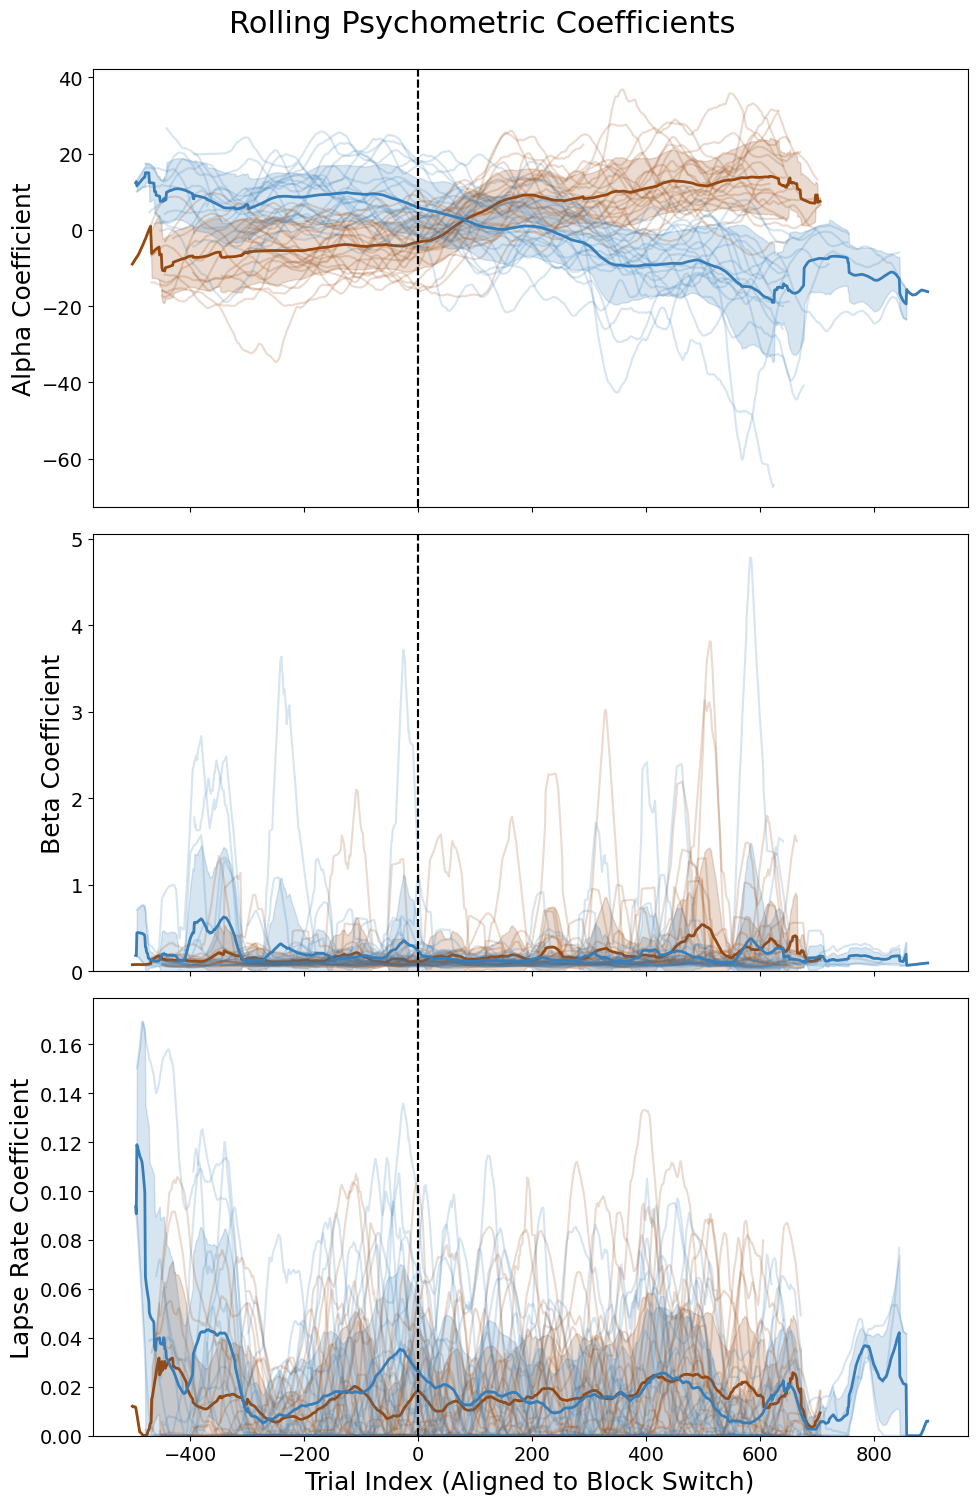

In [22]:
def smooth_2d(array2d, window_size=30):
    kernel = np.ones(window_size) / window_size
    return np.array([np.convolve(row, kernel, mode='same') for row in array2d])

def get_mean_and_std(series, axis=0):
    mean_series = np.nanmean(series, axis=axis)
    std_series = np.nanstd(series, axis=axis)
    sem_series = std_series / np.sqrt(np.sum(~np.isnan(series), axis=axis))
    return mean_series, std_series, sem_series

def plot_individual_and_mean(series, ax, x_range=range(-1000, 1500), error="std", color='k', title=None, window_size=30):
    series = smooth_2d(series, window_size=window_size)
    mean_series, std_series, sem_series = get_mean_and_std(series)

    # Individual traces
    ax.plot(x_range, series.T, color=color, alpha=0.2)
    # Mean trace
    ax.plot(x_range, mean_series, color=color, linewidth=2)

    # Error band
    if error == "std":
        ax.fill_between(x_range, mean_series - std_series, mean_series + std_series, color=color, alpha=0.2)
    elif error == "sem":
        ax.fill_between(x_range, mean_series - sem_series, mean_series + sem_series, color=color, alpha=0.2)

    # Vertical line at block switch
    ax.axvline(0, color='k', linestyle='--')
    ax.tick_params(labelsize=14)

    # Label
    if title:
        ax.set_ylabel(f"{title} Coefficient", fontsize=18)

# Create figure and axes
fig, axs = plt.subplots(3, 1, figsize=(10, 15), sharex=True)

# Alpha
plot_individual_and_mean(all_left_alphas, color=uneq_color['L'], ax=axs[0], title='Alpha')
plot_individual_and_mean(all_right_alphas, color=uneq_color['R'], ax=axs[0])

# Beta
plot_individual_and_mean(all_left_beta, color=uneq_color['L'], ax=axs[1], title='Beta')
plot_individual_and_mean(all_right_beta, color=uneq_color['R'], ax=axs[1])
axs[1].set_ylim([0, axs[1].get_ylim()[1]])

# Lapse Rate
plot_individual_and_mean(all_left_lapse_rate, color=uneq_color['L'], ax=axs[2], title='Lapse Rate')
plot_individual_and_mean(all_right_lapse_rate, color=uneq_color['R'], ax=axs[2])
axs[2].set_xlabel("Trial Index (Aligned to Block Switch)", fontsize=18)
axs[2].set_ylim([0, axs[2].get_ylim()[1]])

# Global figure title
fig.suptitle("Rolling Psychometric Coefficients", fontsize=22, y=1)
plt.tight_layout()
plt.show()
